In [1]:
!pip install langchain-huggingface

In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain.messages import AIMessage,HumanMessage,SystemMessage
import os
import operator
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate
from typing import Literal,TypedDict,Annotated
from langchain_core.output_parsers import PydanticOutputParser

In [3]:
import os
from google.colab import userdata

# 1. Get the key from Colab Secrets
api_key = userdata.get("APIKEY")

# 2. Set it as an environment variable (Crucial step)
os.environ["HUGGINGFACEHUB_API_TOKEN"] = api_key


In [4]:
load_dotenv()

llm1 =HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    huggingfacehub_api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

llm2 =HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    huggingfacehub_api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

llm3 =HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    huggingfacehub_api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

generator_llm = ChatHuggingFace(llm = llm1)
evaluator_llm = ChatHuggingFace(llm = llm2)
optimizer_llm  = ChatHuggingFace(llm = llm3)

In [5]:
class Tweetevalution(BaseModel):
    evaluation:Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback:str = Field(...,description = "feedback for the tweet.")

In [6]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [7]:
parser1 = PydanticOutputParser(pydantic_object=Tweetevalution)

In [8]:
prompt1 = PromptTemplate(
    template = "{prompt}",
    input_variables=["prompt"],
    partial_variables={"format_instructions": parser1.get_format_instructions()}
)

In [9]:
structured_evaluator_llm = prompt1 | evaluator_llm | parser1

In [10]:
def generate_tweet(state:TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages)
    return {"tweet":response,"tweet_history":[response]}



In [11]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [12]:
def optimize_tweet(state:TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = optimizer_llm.invoke(messages)
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [13]:
def route_evaluation(state:TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'

    else:
        return 'needs_improvement'

In [14]:
graph = StateGraph(TweetState)

In [15]:
graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize",optimize_tweet)

In [16]:
graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")

graph.add_conditional_edges("evaluate",route_evaluation,{"approved":END,"needs_improvement":"optimize"})
graph.add_edge("optimize","evaluate")

In [17]:
workflow = graph.compile()

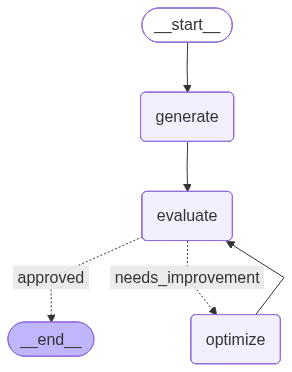

In [18]:

workflow

In [19]:
initial_state = {
    "topic": "Ai",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

OutputParserException: Invalid json output: - evaluation: "approved"
- feedback: The tweet is original in its approach by humorously spinning the AI's existential crisis into a relatable problem for content creators. It's also quite punchy and scroll-stopping, with a clever use of quotes to emphasize the point. The tweet is under 280 characters and doesn't follow a traditional setup-punchline format. However, it could benefit from a bit more playfulness in the punchline to potentially enhance the humor and make it even more scroll-stopping. Overall, it's a solid tweet that could gain traction on Twitter.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 